# Convergence plots

In [1]:
# Directives on Jupyter
%reset
# Auto reload bootstrap.py
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import sys
import os

module_path = os.path.abspath(os.path.join("../src"))
if module_path not in sys.path:
    sys.path.append(module_path)

output_path = os.path.abspath("../../../OneDrive - Rice University/Documents/Research/Hubbard Tweezer Parameters/output/Hubbard/")

## Convergence vs $\Delta x$

Wannier: Number of integration grid set to 257.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: Number of integration grid set to 257.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: Number of integration grid set to 257.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: N

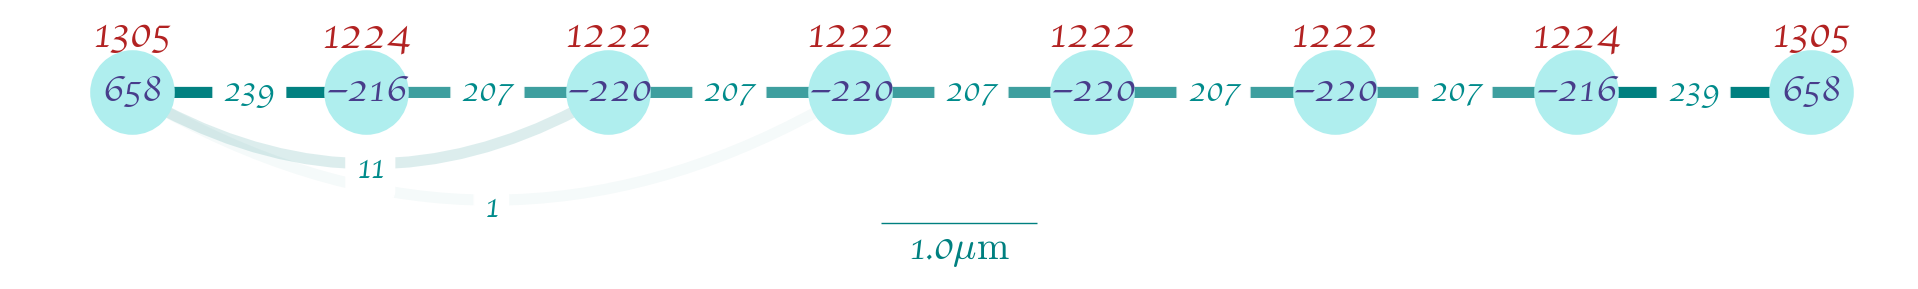

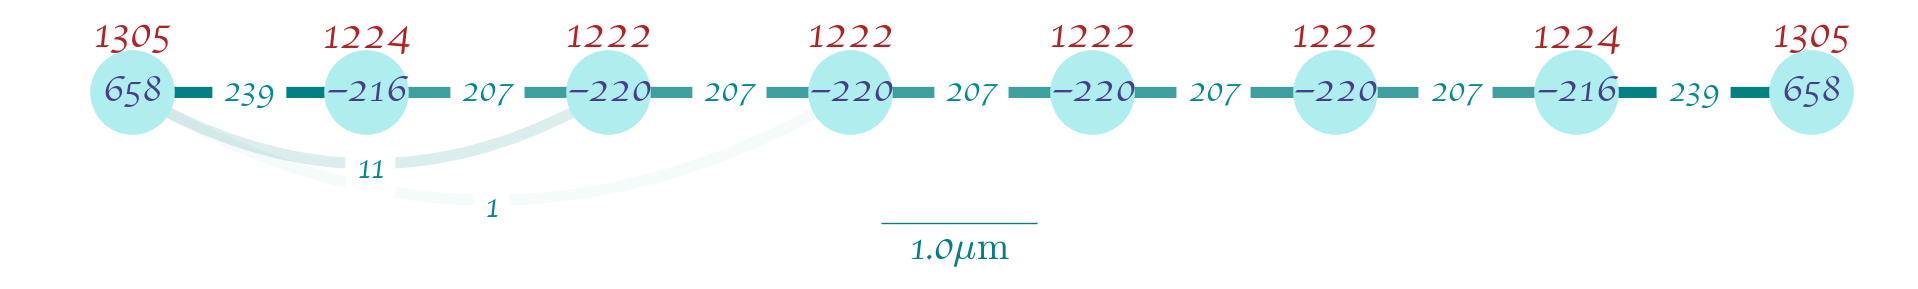

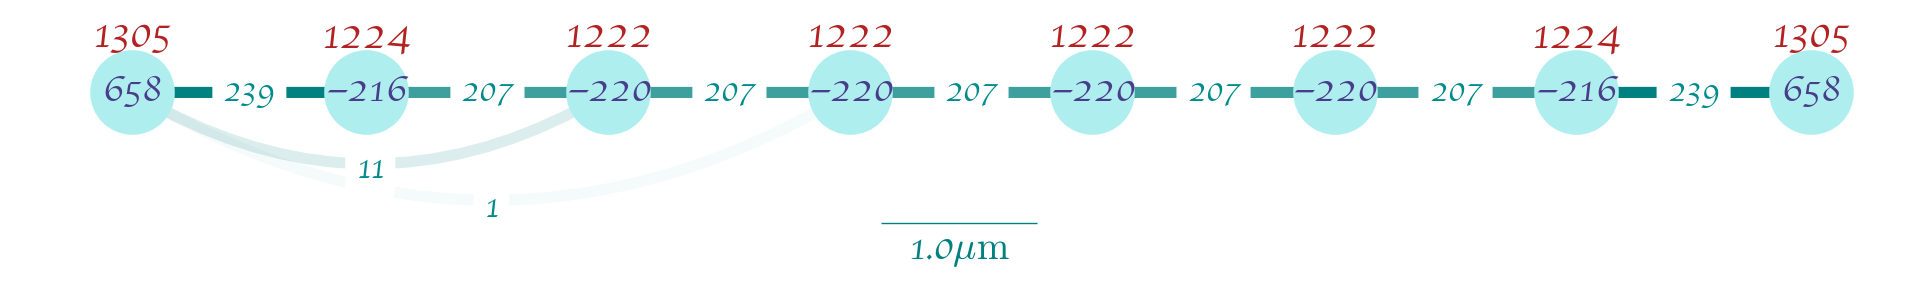

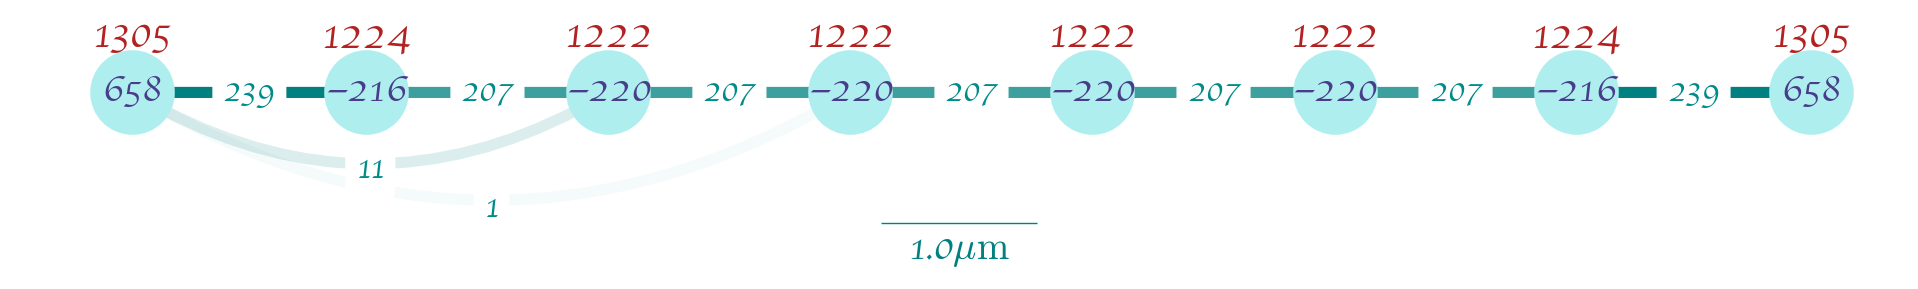

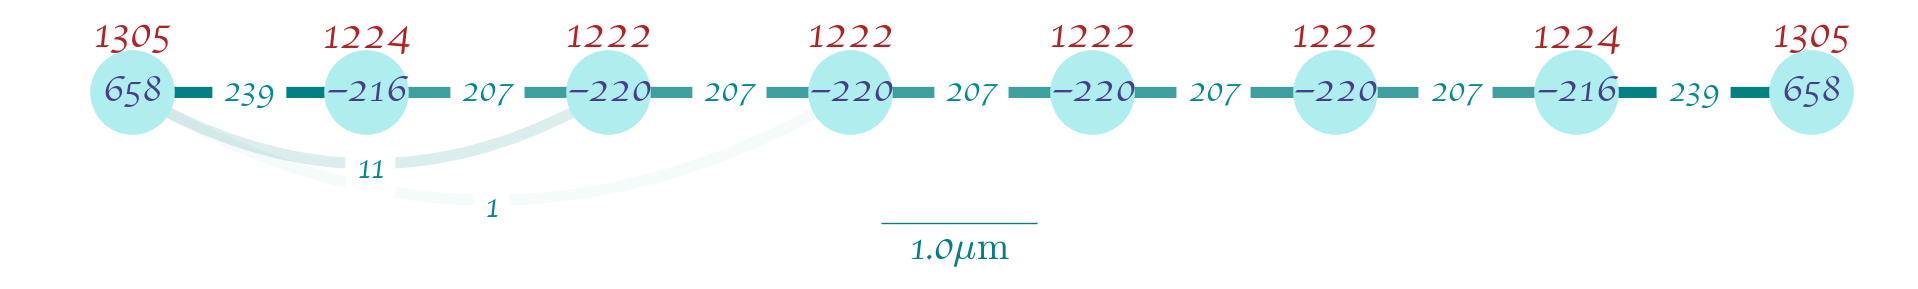

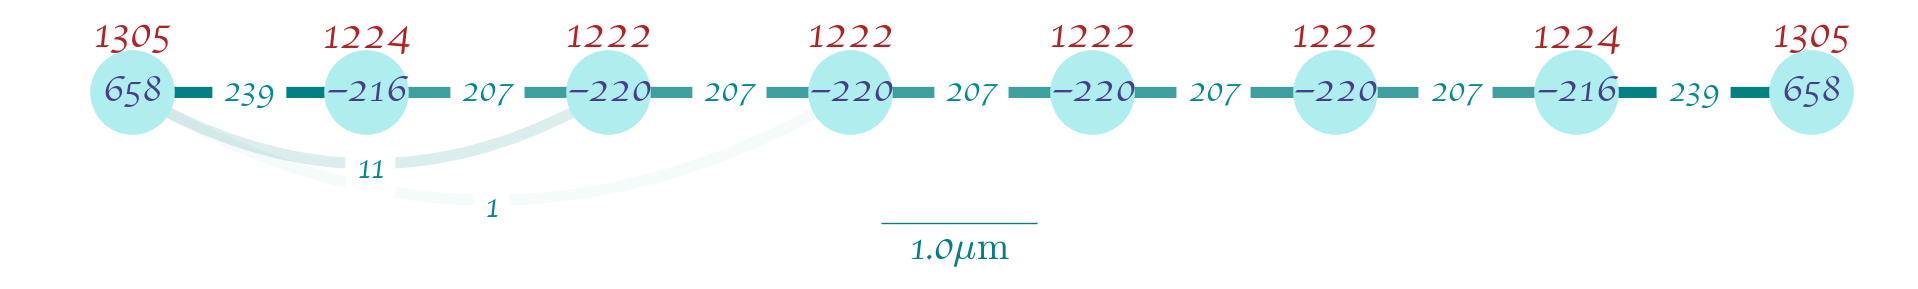

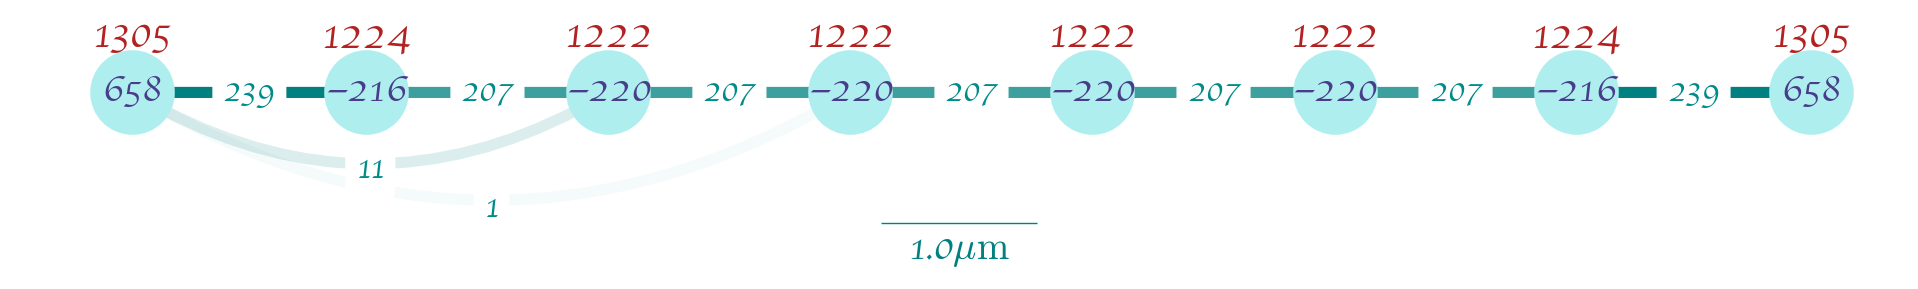

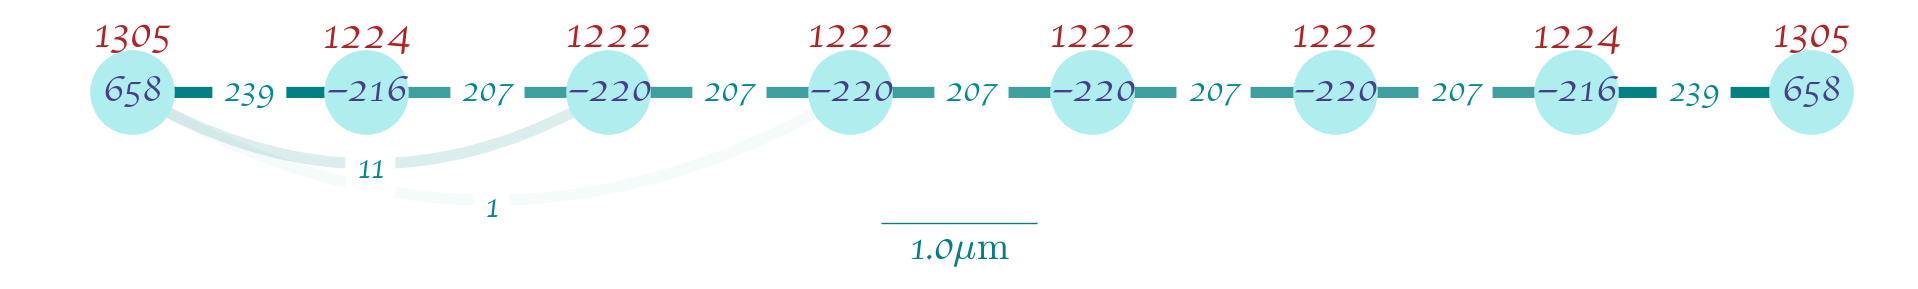

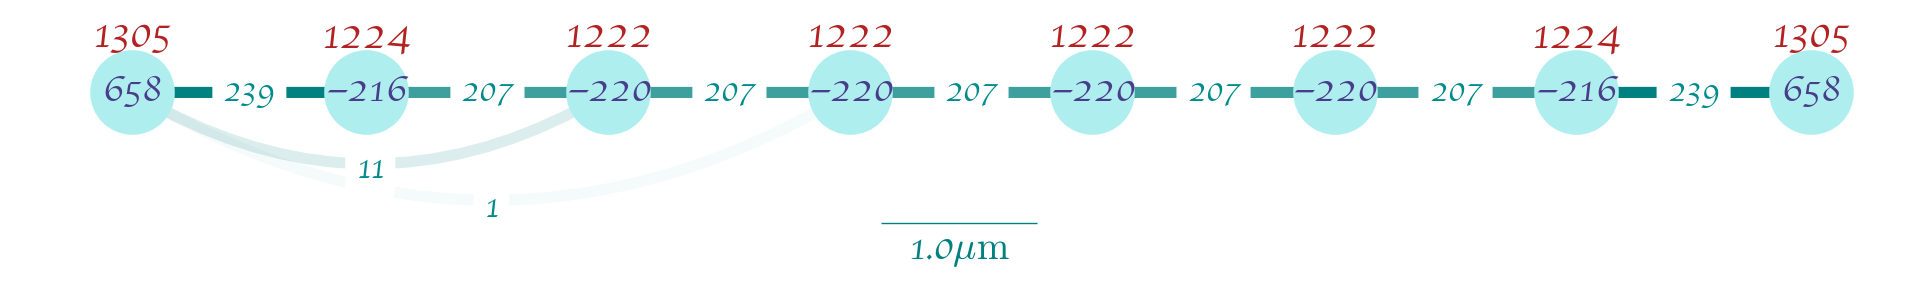

In [7]:
from HubbardTweezer.Hubbard.plot import *
import numpy as np
from HubbardTweezer.Hubbard.io import *


L = 8
Ly = 1
d = 3
shape = "square"
w = None
eqt = ""
R0 = np.array([3, 3, 7.2])
A_list = []
t_list = []
V_list = []
U_list = []
N_list = list(range(12, 30, 2))
for N in N_list:
    G = HubbardGraph(
        N,
        R0=R0,
        lattice_params=(np.array([L, Ly], dtype=int),(1550, 1600)),
        trap=(52.26, 1000),
        ascatt=1770,
        laser=780,
        band=1,
        dim=d,
        sparse=True,
        shape=shape,
        equalize=False,
        verbosity=0,
    )

    fn = os.path.join(output_path, f"convergence/{d}D_{L}x1_{shape}_{w}_N_{N}.ini")
    report = rep.get_report(fn)
    G = read_file(report, G)
    G.draw_graph(nnn=2, A=G.A, U=G.U)
    # G.draw_graph(nnn=2)
    A_list.append(G.A)
    t_list.append(abs(G.nn_tunneling(G.A)))
    V_list.append(abs(np.diag(G.A)))
    U_list.append(G.U)
print(f"V = {np.diag(G.A)}")
t = abs(G.nn_tunneling(G.A))
print(f"t = {t}")
print(f"U = {G.U}")
print(f"V_err = {G.v_cost_func(G.A, None)}")
print(f"t_err = {G.t_cost_func(G.A, None, None, None)}")
print(f"U_err = {G.u_cost_func(G.U, None)}")

dx = 0.107, max_err t = 2.1814942961183564e-05, max_err U = 4.751870792711931e-12 max_err = 2.1814942961183564e-05
dx = 0.115, max_err t = 2.0208340375345846e-05, max_err U = 4.733913194190021e-12 max_err = 2.0208340375345846e-05
dx = 0.125, max_err t = 2.5104299120931714e-05, max_err U = 5.503369082371263e-12 max_err = 2.5104299120931714e-05
dx = 0.136, max_err t = 2.1985152518201594e-05, max_err U = 3.403369509972342e-11 max_err = 2.1985152518201594e-05
dx = 0.15, max_err t = 2.2976329208986052e-05, max_err U = 1.2078607975741424e-09 max_err = 2.2976329208986052e-05
dx = 0.167, max_err t = 2.1693842220422713e-05, max_err U = 4.018697892395359e-08 max_err = 2.1693842220422713e-05
dx = 0.188, max_err t = 4.2203369394090995e-05, max_err U = 1.0506247619014066e-06 max_err = 4.2203369394090995e-05
dx = 0.214, max_err t = 1.3715693126297275e-05, max_err U = 2.5209523237247416e-05 max_err = 2.5209523237247416e-05
dx = 0.25, max_err t = 0.011327667864460494, max_err U = 0.0004582642645254491

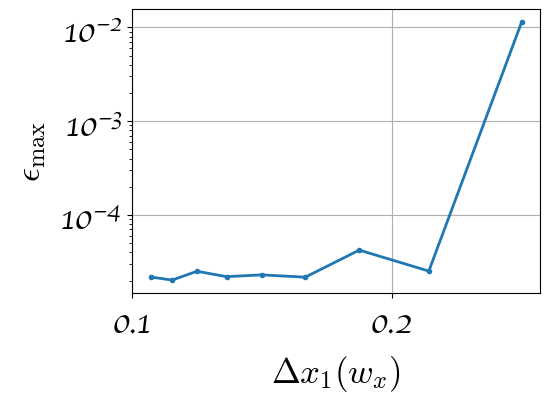

In [8]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

size = 25
params = {
    "figure.figsize": (6, 4.5),
    "legend.fontsize": "xx-large",
    "axes.labelsize": size,
    "axes.titlesize": "xx-large",
    "xtick.labelsize": size,
    "ytick.labelsize": size,
}
plt.rcParams.update(params)
plt.gcf().subplots_adjust(bottom=0.25, left=0.22)

dx = 3 / np.array(N_list)[::-1]
tarr = np.array(A_list)[::-1]
Uarr = np.array(U_list)[::-1]
Uinf = np.zeros_like(Uarr[0])
tinf = np.zeros_like(tarr[0])
fitrange = slice(0, 3)
for i in range(L):
    pU = np.polyfit(dx[fitrange], np.log(Uarr[fitrange, i]), 1)
    Uinf[i] = np.exp(pU[1])
    for j in range(L):
        pt = np.polyfit(dx[fitrange], np.log(abs(tarr[fitrange, i, j])), 1)
        tinf[i, j] = np.exp(pt[1])

max_err = np.zeros_like(dx)
for i in range(len(max_err)):
    met = np.max((abs(tarr[i]) - abs(tinf)) / abs(tinf))
    meu = np.max((abs(Uarr[i]) - abs(Uinf)) / abs(Uinf))
    me = max(met, meu)
    print(f"dx = {dx[i]:.3g}, max_err t = {met}, max_err U = {meu} max_err = {me}")
    max_err[i] = me
plt.plot(dx, max_err, ".-", lw=2)

plt.xlabel("$\Delta x_1(w_x)$")
plt.ylabel("$\epsilon_\mathrm{max}$")
plt.yscale("log")
plt.grid()
plt.savefig("AppFig1.pdf")

Do the same thing as the one below

dx = 0.25, max_err t = 2.506288609137196e-06, max_err V = 0.0006531957923887783, max_err U = 0.00045826427258310453 max_err = 0.0006531957923887783
dx = 0.214, max_err t = -8.624218876814555e-07, max_err V = 1.371575310338699e-05, max_err U = 2.520953010030669e-05 max_err = 2.520953010030669e-05
dx = 0.188, max_err t = -1.1050242969686264e-08, max_err V = 2.2617681404556827e-07, max_err U = 1.050634159461083e-06 max_err = 1.050634159461083e-06
dx = 0.167, max_err t = -2.7431278712052533e-10, max_err V = 8.237905979988832e-09, max_err U = 4.0196833800860555e-08 max_err = 4.0196833800860555e-08
dx = 0.15, max_err t = 3.7929640017375114e-11, max_err V = 9.005055341060754e-11, max_err U = 1.2172568155422431e-09 max_err = 1.2172568155422431e-09
dx = 0.136, max_err t = 4.468922175975283e-11, max_err V = 5.643903043088722e-11, max_err U = 4.388875332464056e-11 max_err = 5.643903043088722e-11
dx = 0.125, max_err t = 4.441913709919137e-11, max_err V = 5.612465650100801e-11, max_err U = 1.236625

/Users/nottforestfc/miniforge3/envs/torch/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


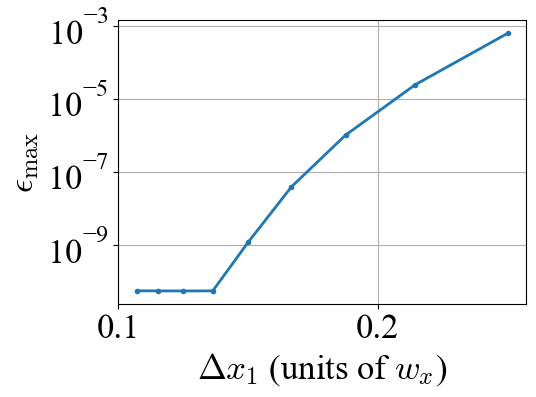

In [13]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def exp_fit(x, a, b, c):
    return a * np.exp(-b * x) + c


size = 25
params = {
    "figure.figsize": (6, 4.5),
    "legend.fontsize": "xx-large",
    "axes.labelsize": size,
    "axes.titlesize": "xx-large",
    "xtick.labelsize": size,
    "ytick.labelsize": size,
}
plt.rcParams.update(params)
plt.gcf().subplots_adjust(bottom=0.25, left=0.22)

Narr = np.array(N_list)
tarr = np.array(t_list)
Varr = np.array(V_list)
Uarr = np.array(U_list)
Uinf = np.zeros_like(Uarr[0])
tinf = np.zeros_like(tarr[0])
Vinf = np.zeros_like(Varr[0])
fitrange = slice(-3, None)
for i in range(L):
    # pU = np.polyfit(dx[fitrange], np.log(Uarr[fitrange, i]), 1)
    # Uinf[i] = np.exp(pU[1])
    # pV = np.polyfit(dx[fitrange], np.log(Varr[fitrange, i]), 1)
    # Vinf[i] = np.exp(pV[1])
    popU, pcovU = curve_fit(
        exp_fit, Narr[fitrange], Uarr[fitrange, i], p0=[1, 1, Uarr[0, i]]
    )
    Uinf[i] = popU[2]
    popV, pcovV = curve_fit(
        exp_fit, Narr[fitrange], abs(Varr[fitrange, i]), p0=[1, 1, Varr[0, i]]
    )
    Vinf[i] = popV[2]
for j in range(len(tarr[0])):
    # pt = np.polyfit(dx[fitrange], np.log(abs(tarr[fitrange, j])), 1)
    # tinf[j] = np.exp(pt[1])
    popt, pcovt = curve_fit(
        exp_fit, Narr[fitrange], abs(tarr[fitrange, j]), p0=[1, 1, 1]
    )
    tinf[j] = popt[2]

max_err = np.zeros_like(Narr, dtype=float)
for i in range(len(max_err)):
    met = np.max((abs(tarr[i]) - abs(tinf)) / abs(tinf))
    mev = np.max((abs(Varr[i]) - abs(Vinf)) / abs(Vinf))
    meu = np.max((abs(Uarr[i]) - abs(Uinf)) / abs(Uinf))
    me = max(met, mev, meu)
    print(
        f"dx = {3 / Narr[i]:.3g}, max_err t = {met}, max_err V = {mev}, max_err U = {meu} max_err = {me}"
    )
    max_err[i] = me
plt.plot(3 / Narr, max_err, ".-", lw=2)

plt.xlabel("$\Delta x_1$ (units of $w_x$)")
plt.ylabel("$\epsilon_\mathrm{max}$")
plt.yscale("log")
plt.grid()
plt.savefig("AppFig1.pdf")

### TODO: check why only for $\Delta x$ there's a plateau at the end!

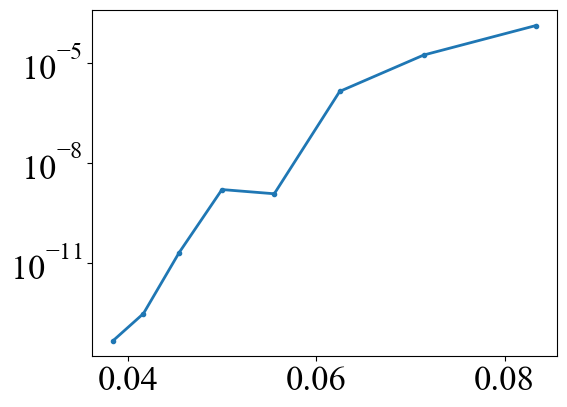

In [14]:
plt.plot(1 / Narr[:-1], abs(np.diff(Uarr, axis=0)[:, 0]), ".-", lw=2)
plt.yscale("log")

In [221]:
print(np.diff(Uarr[fitrange, 0]))
print(Uarr[fitrange, 0])
print(dx[fitrange])
print(popU)

[4.59632332e-14 2.95541369e-13 1.99120720e-11]
[1.30456864 1.30456864 1.30456864 1.30456864]
[0.10714286 0.11538462 0.125      0.13636364]
[-2.58832992e-07  2.54265792e-01  1.30456891e+00]


In [292]:
Uarr[:, 0] - popU[2]

array([ 1.47577338e-04,  1.82675512e-05,  1.37002330e-06,  2.14800888e-09,
        9.86911664e-10, -5.66437119e-10])

/Users/nottforestfc/miniforge3/envs/torch/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


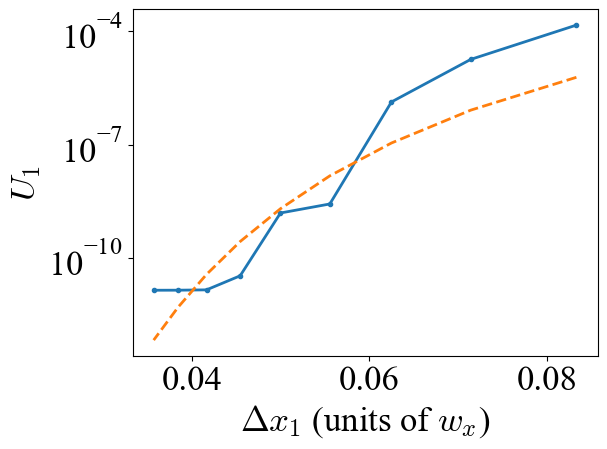

In [15]:
fitrange = slice(-3, None)
popU, pcovU = curve_fit(exp_fit, Narr[fitrange], Uarr[fitrange, 0])
eps = 1e-10

plt.plot(1 / Narr, abs(Uarr[:, 0] - popU[2]), ".-", lw=2)
plt.plot(1 / Narr, exp_fit(Narr, *popU) - popU[2], "--", lw=2)
plt.xlabel("$\Delta x_1$ (units of $w_x$)")
plt.ylabel("$U_{1}$")
plt.yscale("log")
# plt.ylim([Aplot[1] - exp_fit(0, *popU), Aplot[1] - popU[2] + 11e-9])

## Convergence vs $L$

Wannier: Number of integration grid set to 257.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: Number of integration grid set to 257.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: Number of integration grid set to 257.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: N

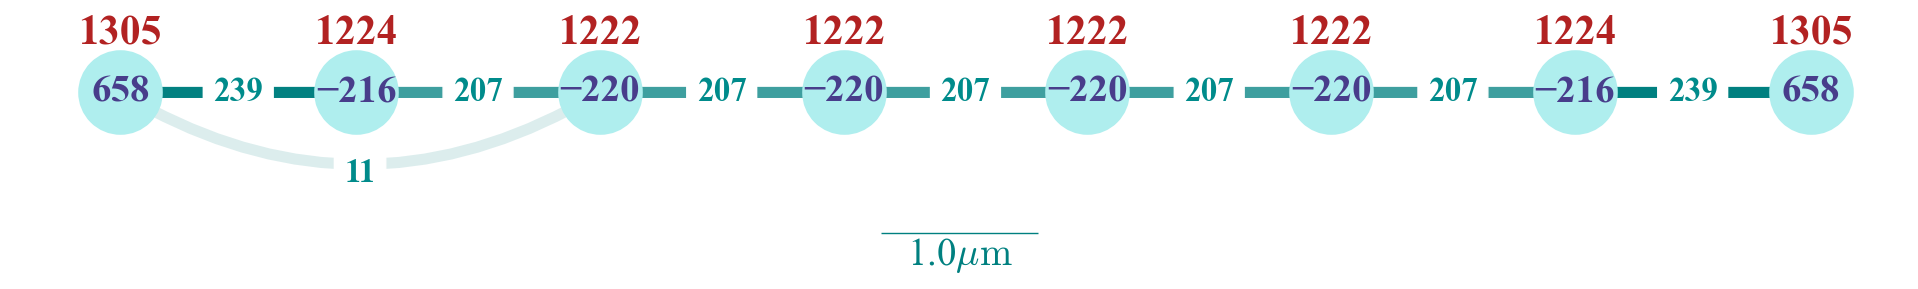

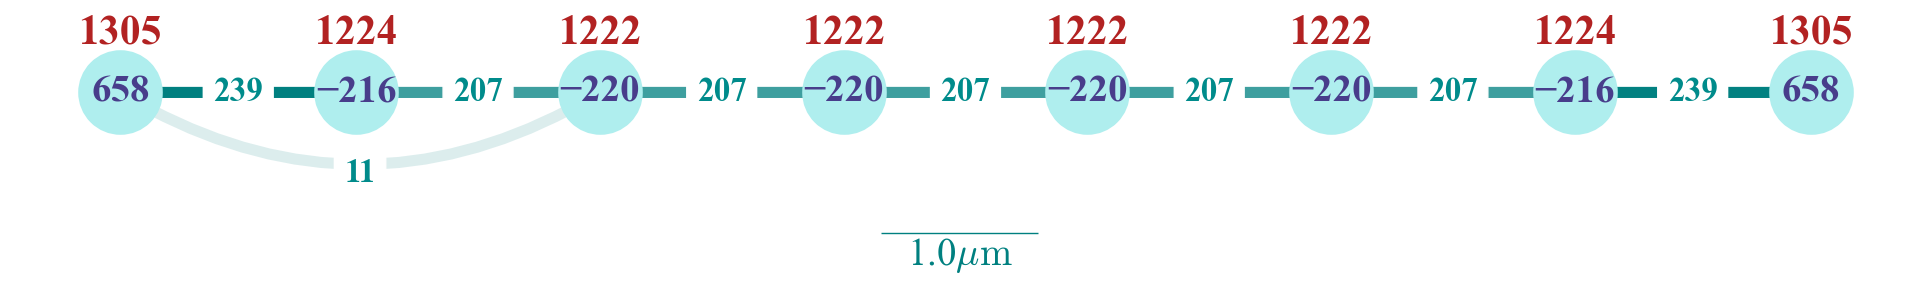

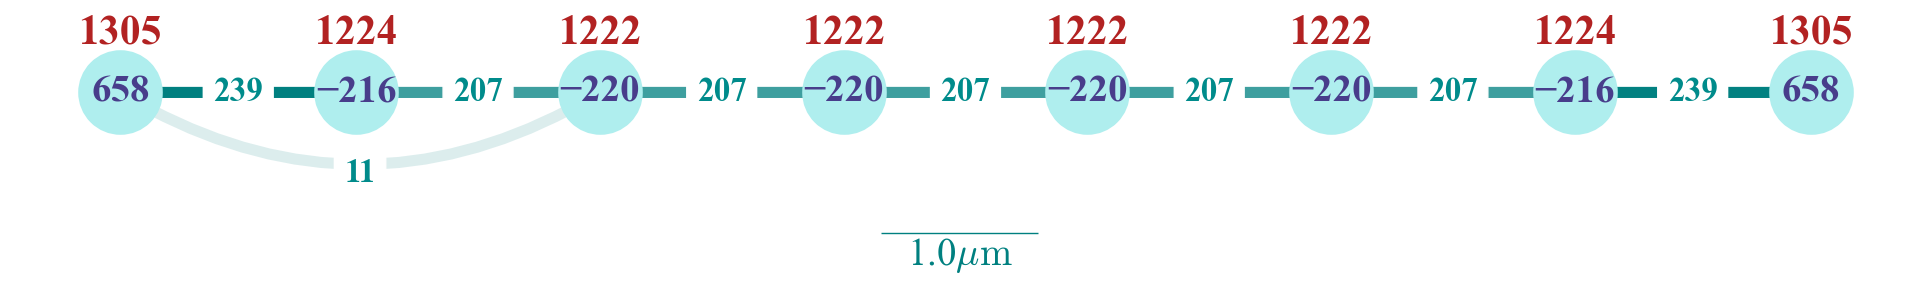

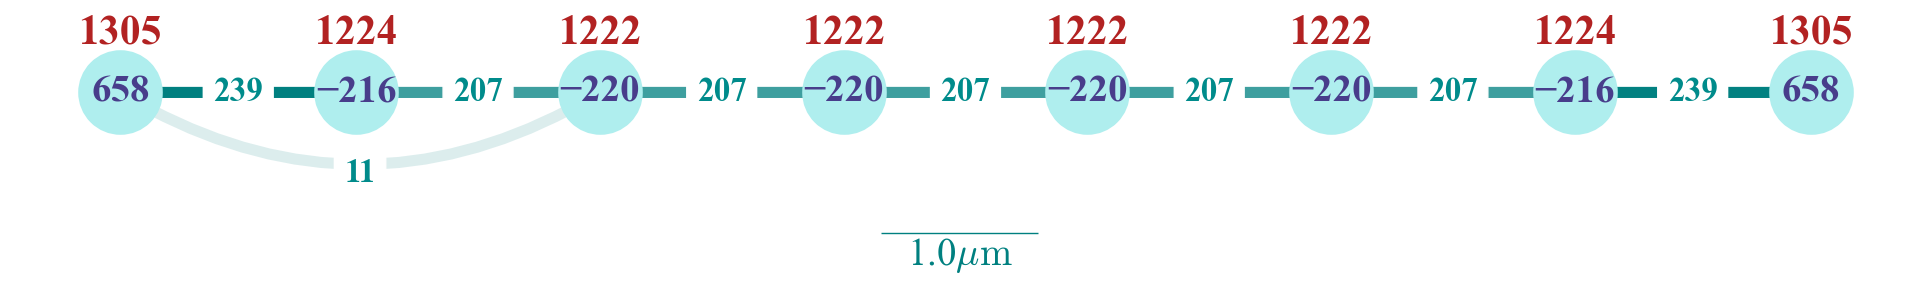

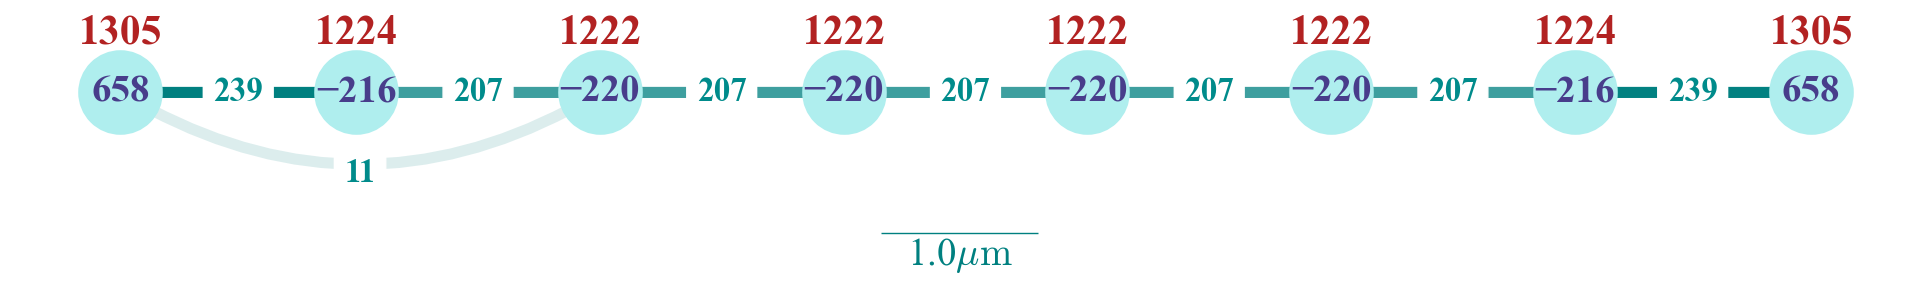

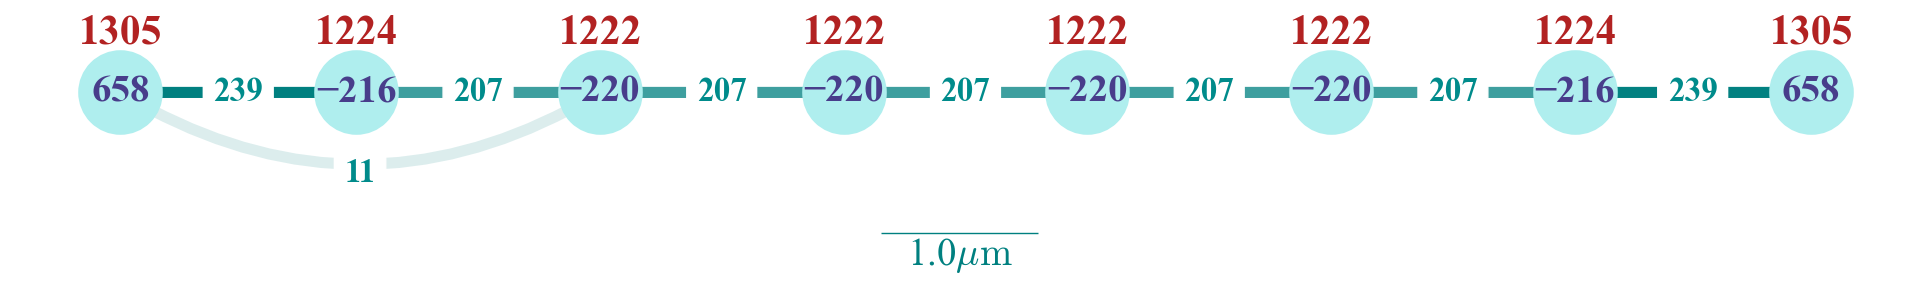

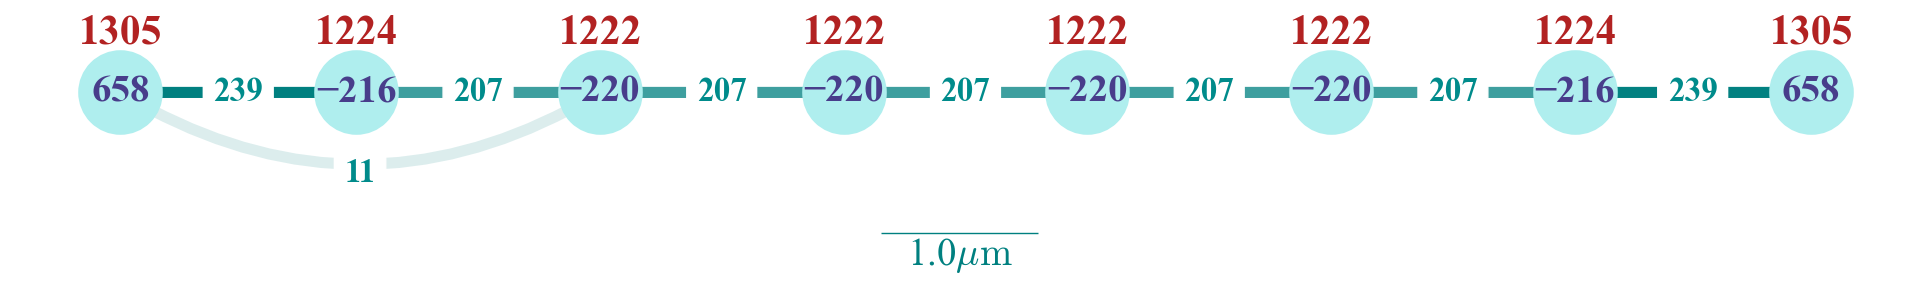

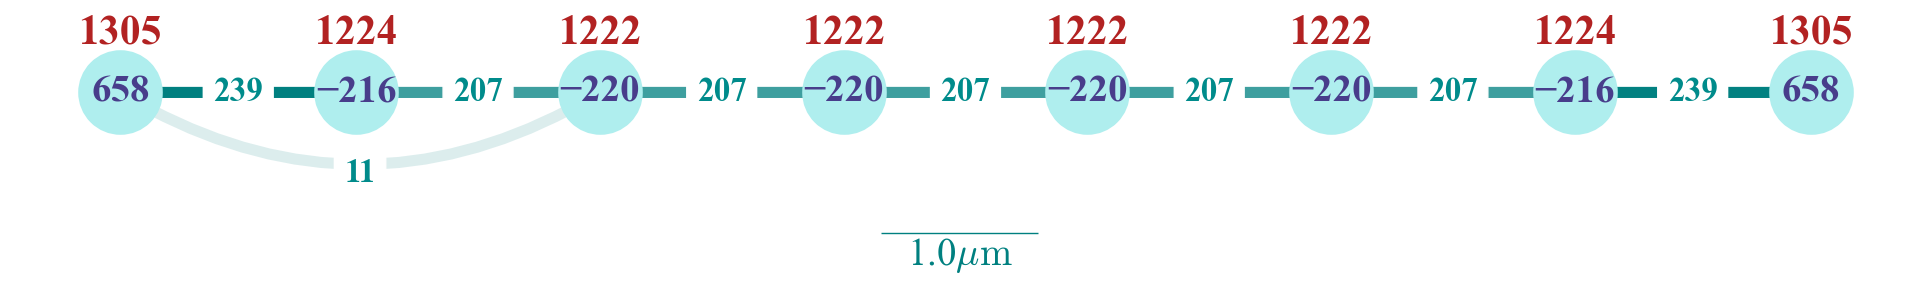

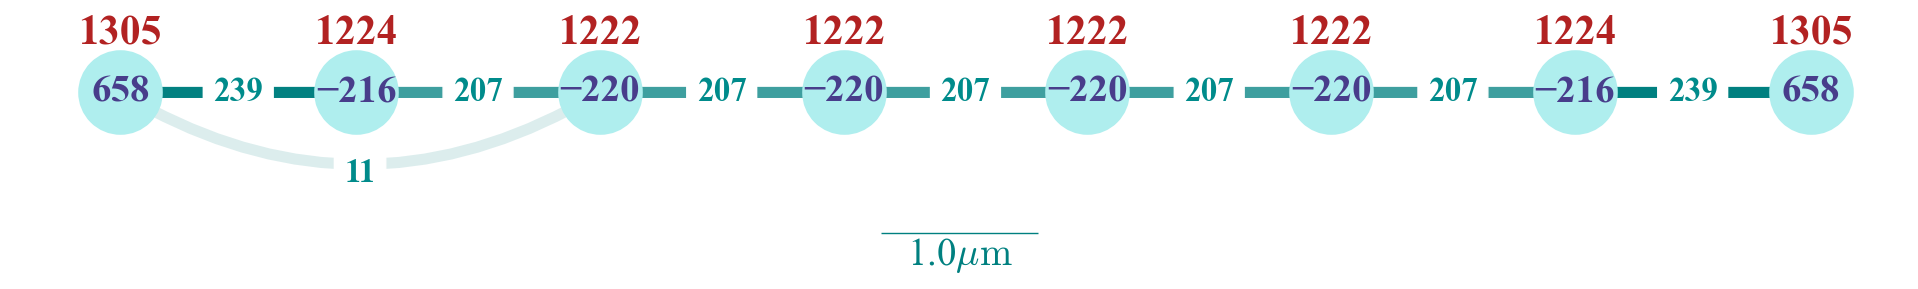

In [16]:
from HubbardTweezer.Hubbard.plot import *
import numpy as np
from HubbardTweezer.Hubbard.io import *

L = 8
Ly = 1
d = 3
shape = "square"
w = None
eqt = ""
A_list = []
t_list = []
V_list = []
U_list = []
N_list = range(12, 30, 2)
for N in N_list:
    R0 = np.array([1, 1, 2.4]) * N * 3 / 20
    G = HubbardGraph(
        N,
        R0=R0,
        lattice_params=(np.array([L, Ly], dtype=int),(1550, 1600)),
        trap=(52.26, 1000),
        ascatt=1770,
        laser=780,
        band=1,
        dim=d,
        sparse=True,
        shape=shape,
        equalize=False,
        verbosity=0,
    )

    fn = os.path.join(output_path, f"convergence/{d}D_{L}x1_{shape}_{w}_L_{N}.ini")
    report = rep.get_report(fn)
    G = read_file(report, G)
    G.draw_graph(nnn=True, A=G.A, U=G.U)
    A_list.append(G.A)
    t_list.append(abs(G.nn_tunneling(G.A)))
    V_list.append(abs(np.diag(G.A)))
    U_list.append(G.U)
print(f"V = {np.diag(G.A)}")
t = abs(G.nn_tunneling(G.A))
print(f"t = {t}")
print(f"U = {G.U}")
print(f"V_err = {G.v_cost_func(G.A, None)}")
print(f"t_err = {G.t_cost_func(G.A, None, None, None)}")
print(f"U_err = {G.u_cost_func(G.U, None)}")

[array([1.8 , 1.8 , 4.32]), array([2.1 , 2.1 , 5.04]), array([2.4 , 2.4 , 5.76]), array([2.7 , 2.7 , 6.48]), array([3. , 3. , 7.2]), array([3.3 , 3.3 , 7.92])]
R0x = 1.8 max_err A = 8.52571183585596e-07, max_err U = 8.898151195517909e-08 max_err = 8.52571183585596e-07
R0x = 2.1 max_err A = 5.320716908706395e-06, max_err U = 9.068196059352621e-09 max_err = 5.320716908706395e-06
R0x = 2.4 max_err A = 4.960913595407967e-06, max_err U = 8.07374596588956e-09 max_err = 4.960913595407967e-06
R0x = 2.7 max_err A = 2.2836497020932373e-06, max_err U = 8.059257992968062e-09 max_err = 2.2836497020932373e-06
R0x = 3.0 max_err A = 4.3077524939373826e-06, max_err U = 8.059645260373253e-09 max_err = 4.3077524939373826e-06
R0x = 3.3 max_err A = 5.893536487343557e-06, max_err U = 8.059771144953677e-09 max_err = 5.893536487343557e-06


/Users/nottforestfc/miniforge3/envs/torch/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


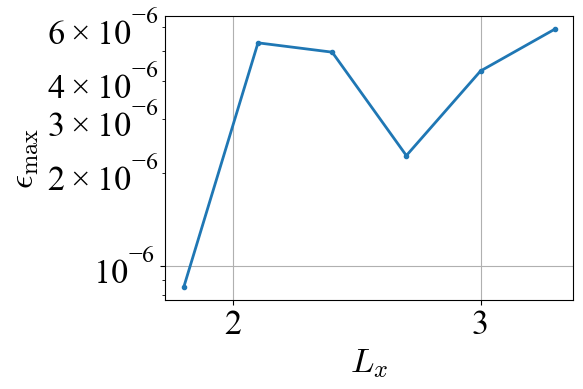

In [17]:
import matplotlib.pyplot as plt

size = 25
params = {
    "figure.figsize": (6, 4.5),
    "legend.fontsize": "xx-large",
    "axes.labelsize": size,
    "axes.titlesize": "xx-large",
    "xtick.labelsize": size,
    "ytick.labelsize": size,
}
plt.rcParams.update(params)
plt.gcf().subplots_adjust(bottom=0.25, left=0.22)

r = np.arange(12, 24, 2)
R0 = [np.array([1, 1, 2.4]) * N * 3 / 20 for N in r]
print(R0)
dx = r * 3 / 20

tarr = np.array(A_list)
Uarr = np.array(U_list)
Uinf = np.zeros_like(Uarr[0])
tinf = np.zeros_like(tarr[0])
fitrange = slice(-4, None)
for i in range(L):
    # pU = np.polyfit(1 / dx[fitrange], np.log(Uarr[fitrange, i]), 1)
    # Uinf[i] = np.exp(pU[1])
    popU, pcovU = curve_fit(exp_fit, 1 / dx[fitrange], Uarr[fitrange, i])
    Uinf[i] = popU[0] + popU[2]
    for j in range(L):
        popt, pcovt = curve_fit(exp_fit, 1 / dx[fitrange], abs(tarr[fitrange, i, j]))
        tinf[i, j] = popt[0] + popt[2]

max_err = np.zeros_like(dx)
for i in range(len(max_err)):
    met = np.max((abs(tarr[i]) - abs(tinf)) / abs(tinf))
    meu = np.max((abs(Uarr[i]) - abs(Uinf)) / abs(Uinf))
    me = max(met, meu)
    print(f"R0x = {dx[i]} max_err A = {met}, max_err U = {meu} max_err = {me}")
    max_err[i] = me
plt.plot(dx, max_err, ".-", lw=2)

plt.xlabel("$L_x$")
plt.ylabel("$\epsilon_\mathrm{max}$")
plt.yscale("log")
plt.grid()
plt.savefig("AppFig2.pdf")

Why error is not monotonically decaying? The problem is at the smallest quantity in the calculation $A_{81}\sim 10^{-7}$.

In [87]:
for i in range(L):
    print(abs(Uarr[:, i] - Uinf[i]) / abs(Uinf[i]))

[8.96700255e-08 1.85392928e-09 2.55951450e-11 4.28730338e-12
 3.74860335e-12 3.52205998e-12]
[5.33898286e-08 1.00596345e-09 1.15073742e-11 2.97316159e-12
 2.59133588e-12 2.44350313e-12]
[5.36172403e-08 1.01123684e-09 1.18904328e-11 2.81365419e-12
 2.44350348e-12 2.31357822e-12]
[5.36151535e-08 1.01097871e-09 1.17884702e-11 2.90677595e-12
 2.51462650e-12 2.39142107e-12]
[5.36151416e-08 1.01096708e-09 1.17764768e-11 2.91767908e-12
 2.52589308e-12 2.40014358e-12]
[5.36172320e-08 1.01122612e-09 1.18818923e-11 2.82092274e-12
 2.45059032e-12 2.31939306e-12]
[5.33898166e-08 1.00595438e-09 1.14959467e-11 2.98422637e-12
 2.59841009e-12 2.45293540e-12]
[8.96700437e-08 1.85394766e-09 2.56123358e-11 4.27096367e-12
 3.73175302e-12 3.50895417e-12]


In [19]:
tarr[:, 0, 7]

array([1.12066473e-07, 1.12066974e-07, 1.12066933e-07, 1.12066633e-07,
       1.12066860e-07, 1.12067038e-07, 1.12066860e-07, 1.12066929e-07,
       1.12066860e-07])

In [20]:
for i in range(L):
    for j in range(L):
        print(i, j, (abs(tarr[:, i, j]) - abs(tinf[i, j])) / abs(tinf[i, j]))

0 0 [ 5.96331503e-08  4.42504775e-10 -7.55080780e-10 -7.79238011e-10
 -7.79669775e-10 -7.79658981e-10 -7.79561834e-10 -7.79820893e-10
 -7.79572628e-10]
0 1 [-2.42811312e-08  1.26714927e-09  1.85561572e-09  1.86872853e-09
  1.86910890e-09  1.86861250e-09  1.86899113e-09  1.86854119e-09
  1.86879427e-09]
0 2 [-8.55716835e-08  5.62184147e-10  2.59825921e-09  2.64201154e-09
  2.64516026e-09  2.64531237e-09  2.64520354e-09  2.63901978e-09
  2.64468023e-09]
0 3 [-1.30193418e-07  9.66040636e-09  1.28618069e-08  1.29571413e-08
  1.29821125e-08  1.29247924e-08  1.29553281e-08  1.29465910e-08
  1.29848803e-08]
0 4 [-1.87773419e-07  6.09524454e-09  1.09825102e-08  9.84074555e-09
  1.01835195e-08  1.08734644e-08  1.06970489e-08  1.15938810e-08
  1.04942558e-08]
0 5 [-2.86215163e-07 -4.77369847e-08 -3.14045875e-08 -4.35667791e-08
 -3.15521716e-08 -3.59131161e-08 -3.50079769e-08 -2.64580922e-08
 -3.08562279e-08]
0 6 [-5.60443620e-07 -3.56023422e-07 -1.89939959e-07 -2.64219680e-07
 -3.29465083e-07 -2

ValueError: x and y must have same first dimension, but have shapes (7,) and (10,)

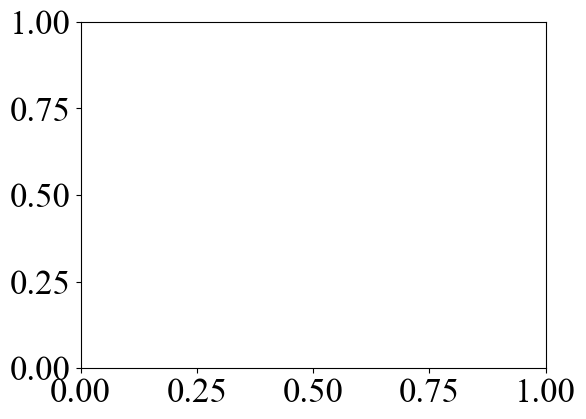

In [21]:
Aplot = tarr[:, 0, 7]
Aplot = np.append(Aplot, tinf[0, 7])
dxplot = np.append(1 / dx, 0)
plt.plot(dxplot, Aplot, ".-", lw=2)
plt.xlabel("$1/L_x$")
plt.ylabel("$A_{18}$")

ValueError: x and y must have same first dimension, but have shapes (7,) and (10,)

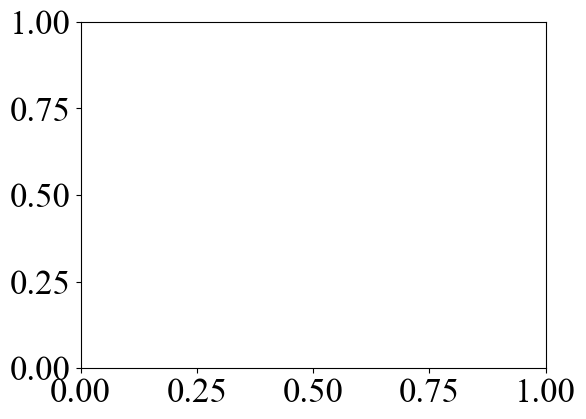

In [22]:
Uplot = Uarr[:, 0]
Uplot = np.append(Uplot, Uinf[0])
dxplot = np.append(1 / dx, 0)
plt.plot(dxplot, Uplot, ".-", lw=2)
plt.xlabel("$1/L_x$")
plt.ylabel("$U_{1}$")

Solution: calculate t,V,U individually

[array([1.8 , 1.8 , 4.32]), array([2.1 , 2.1 , 5.04]), array([2.4 , 2.4 , 5.76]), array([2.7 , 2.7 , 6.48]), array([3. , 3. , 7.2]), array([3.3 , 3.3 , 7.92]), array([3.6 , 3.6 , 8.64]), array([3.9 , 3.9 , 9.36]), array([ 4.2 ,  4.2 , 10.08])]
R0x = 1.8 max_err t = -2.596415619295803e-08, max_err V = 6.261611941080951e-08, max_err U = 9.061859274761747e-08 max_err = 9.061859274761747e-08
R0x = 2.1 max_err t = -4.158757353680461e-10, max_err V = 3.425408921057154e-09, max_err U = 2.8025022636625253e-09 max_err = 3.425408921057154e-09
R0x = 2.4 max_err t = 2.3417866316793893e-10, max_err V = 2.2278773330346315e-09, max_err U = 9.741613175829594e-10 max_err = 2.2278773330346315e-09
R0x = 2.7 max_err t = 2.5298114650371987e-10, max_err V = 2.203687719550604e-09, max_err U = 9.442981023424907e-10 max_err = 2.203687719550604e-09
R0x = 3.0 max_err t = 2.5307890986870986e-10, max_err V = 2.203191190224292e-09, max_err U = 9.44848376345206e-10 max_err = 2.203191190224292e-09
R0x = 3.3 max_err t

/Users/nottforestfc/miniforge3/envs/torch/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


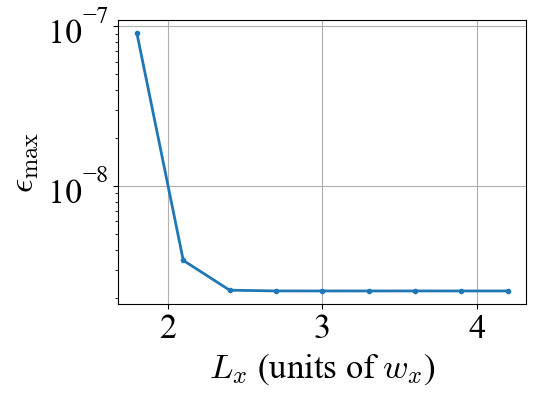

In [23]:
import matplotlib.pyplot as plt


def exp_fit(x, a, b, c):
    return a * np.exp(-b * x) + c


size = 25
params = {
    "figure.figsize": (6, 4.5),
    "legend.fontsize": "xx-large",
    "axes.labelsize": size,
    "axes.titlesize": "xx-large",
    "xtick.labelsize": size,
    "ytick.labelsize": size,
}
plt.rcParams.update(params)
plt.gcf().subplots_adjust(bottom=0.25, left=0.22)

r = np.array(N_list)
R0 = [np.array([1, 1, 2.4]) * N * 3 / 20 for N in r]
print(R0)
dx = r * 3 / 20

tarr = np.array(t_list)
Varr = np.array(V_list)
Uarr = np.array(U_list)
Uinf = np.zeros_like(Uarr[0])
tinf = np.zeros_like(tarr[0])
Vinf = np.zeros_like(Varr[0])
fitrange = slice(-4, None)
for i in range(L):
    # pU = np.polyfit(dx[fitrange], np.log(Uarr[fitrange, i]), 1)
    # Uinf[i] = np.exp(pU[1])
    # pV = np.polyfit(dx[fitrange], np.log(Varr[fitrange, i]), 1)
    # Vinf[i] = np.exp(pV[1])
    popU, pcovU = curve_fit(exp_fit, dx[fitrange], Uarr[fitrange, i])
    Uinf[i] = popU[2]
    popV, pcovV = curve_fit(exp_fit, dx[fitrange], Varr[fitrange, i])
    Vinf[i] = popV[2]
for j in range(len(tinf)):
    # pt = np.polyfit(dx[fitrange], np.log(abs(tarr[fitrange, j])), 1)
    # tinf[j] = np.exp(pt[1])
    popt, pcovt = curve_fit(exp_fit, dx[fitrange], abs(tarr[fitrange, j]))
    tinf[j] = popt[2]


max_err = np.zeros_like(dx)
for i in range(len(max_err)):
    met = np.max((abs(tarr[i]) - abs(tinf)) / abs(tinf))
    mev = np.max((abs(Varr[i]) - abs(Vinf)) / abs(Vinf))
    meu = np.max((abs(Uarr[i]) - abs(Uinf)) / abs(Uinf))
    me = max(mev, meu, met)
    print(
        f"R0x = {dx[i]} max_err t = {met}, max_err V = {mev}, max_err U = {meu} max_err = {me}"
    )
    max_err[i] = me
plt.plot(dx, max_err, ".-", lw=2)

plt.xlabel("$L_x$ (units of $w_x$)")
plt.ylabel("$\epsilon_\mathrm{max}$")
plt.yscale("log")
plt.grid()
plt.savefig("AppFig2.pdf")

## Convergence of $U$ integrals

Wannier: Number of integration grid set to 65.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: Number of integration grid set to 100.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: Number of integration grid set to 129.
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.     1.     1.     1.     1.    -5.425 -3.875
 -2.325 -0.775]
Wannier: Nu

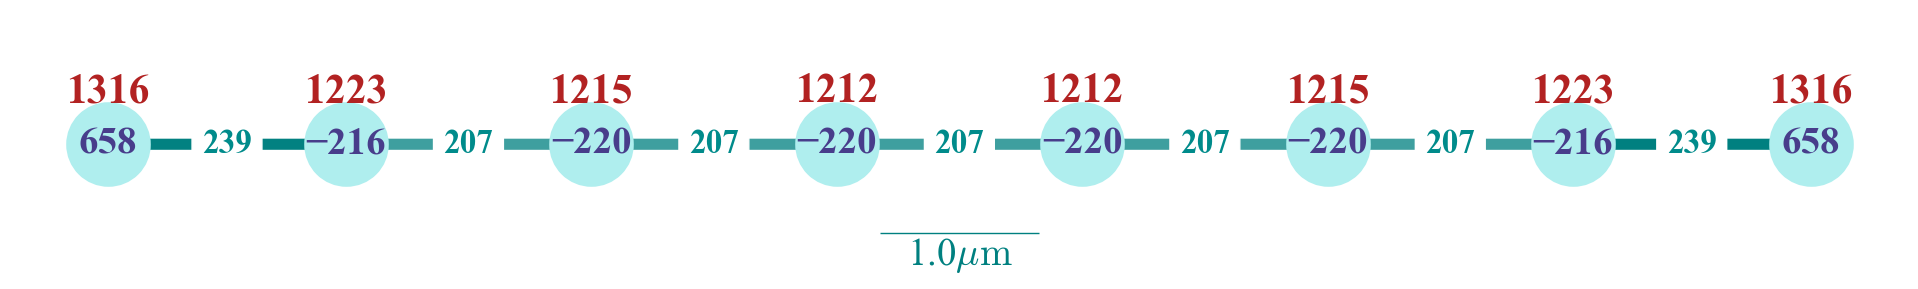

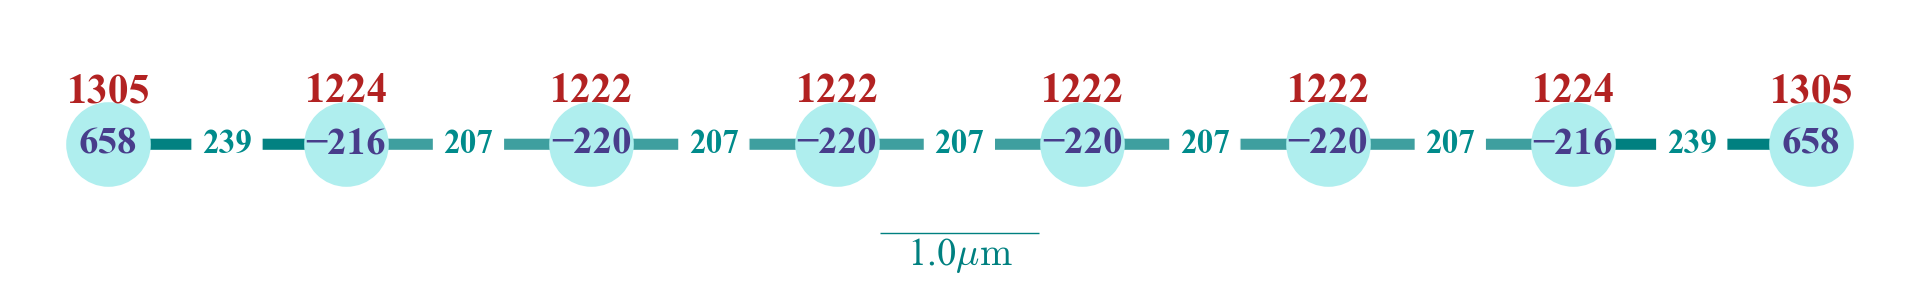

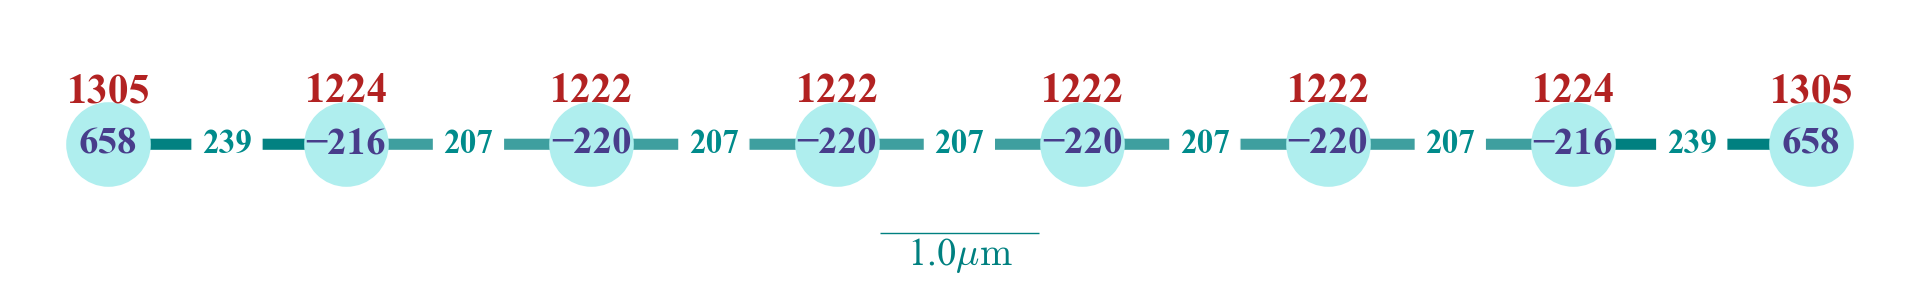

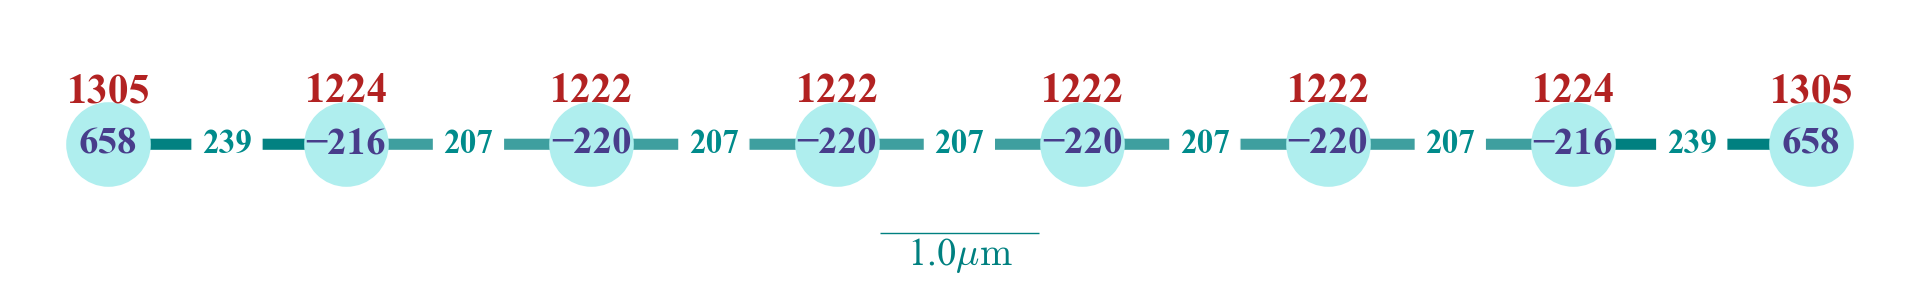

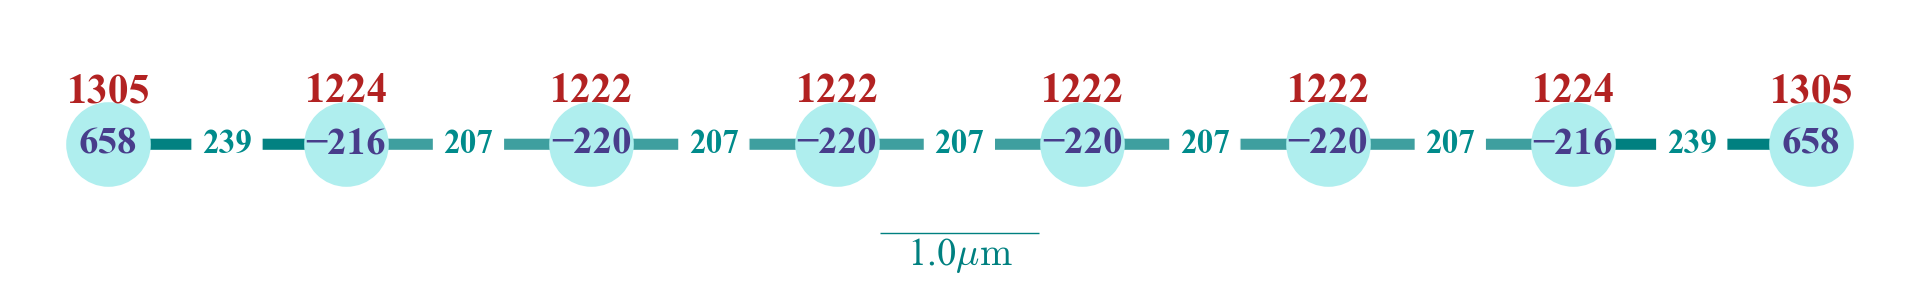

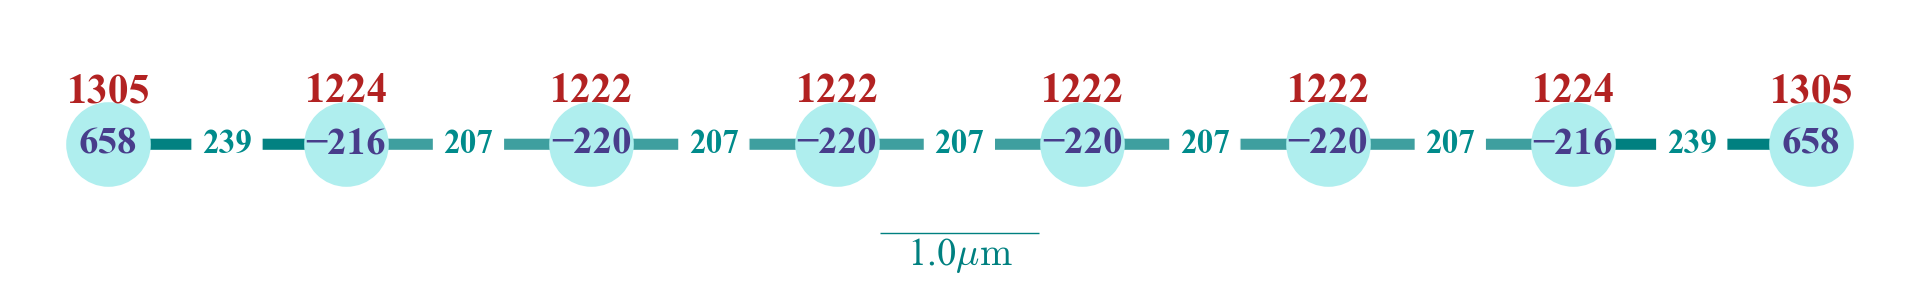

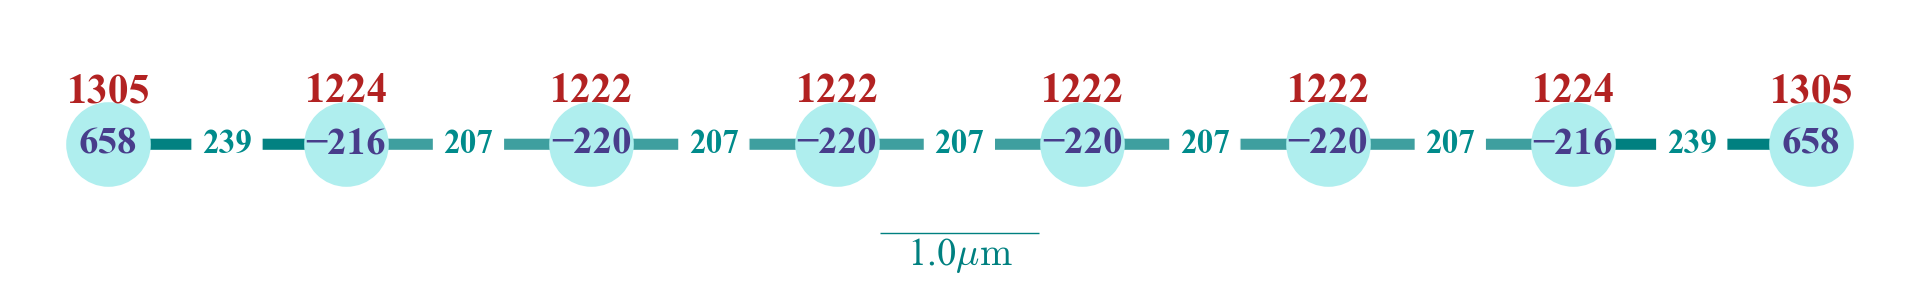

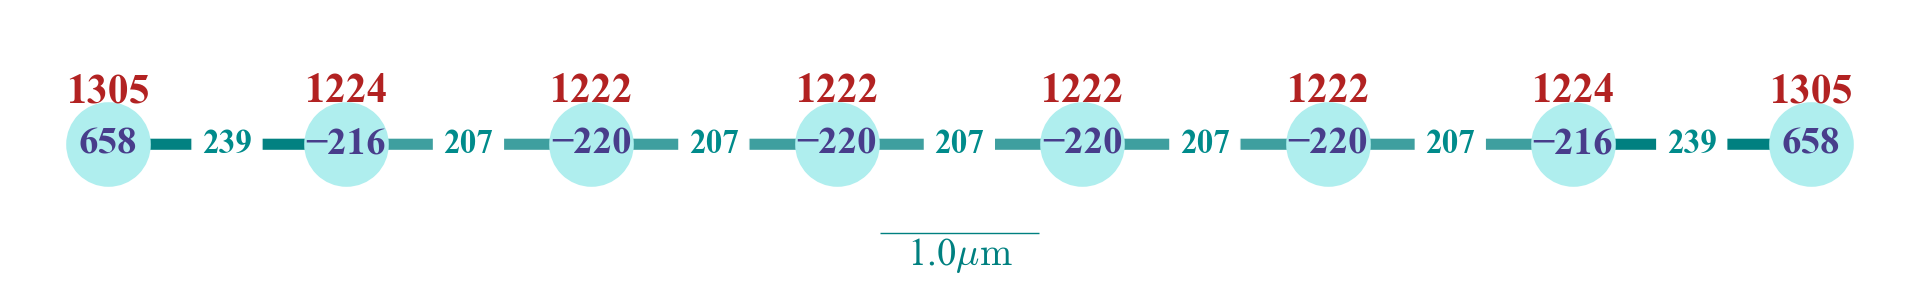

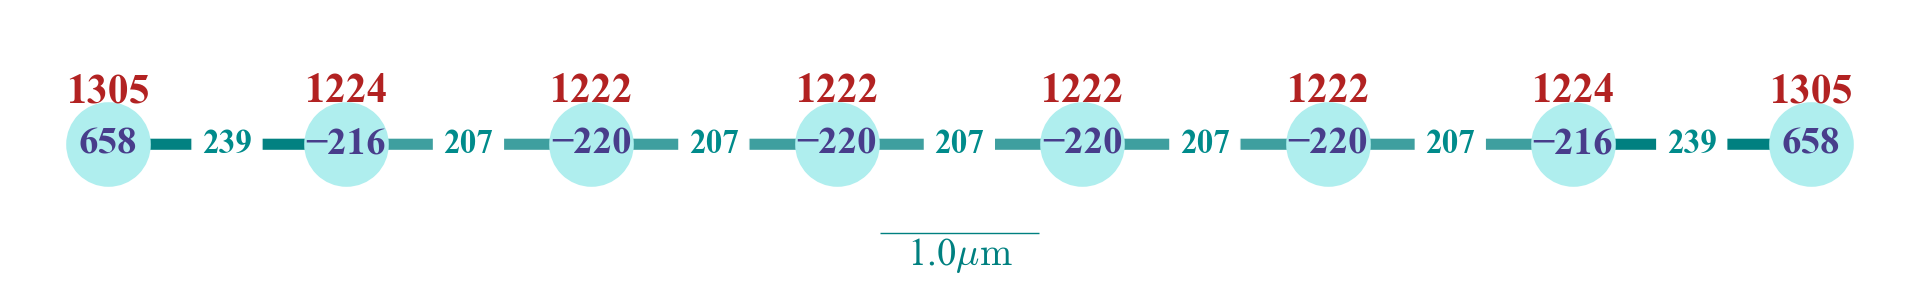

In [25]:
from HubbardTweezer.Hubbard.plot import *
import numpy as np
from HubbardTweezer.Hubbard.io import *


L = 8
Ly = 1
d = 3
shape = "square"
w = None
eqt = ""
R0 = np.array([3, 3, 7.2])
A_list = []
U_list = []
for ig in [65, 100, 129, 150, 175, 200, 225, 257, 300]:
    G = HubbardGraph(
        N=20,
        R0=R0,
        lattice_params=(np.array([L, Ly], dtype=int),(1550, 1600)),
        trap=(52.26, 1000),
        ascatt=1770,
        laser=780,
        band=1,
        dim=d,
        Nintgrl_grid=ig,
        sparse=True,
        shape=shape,
        equalize=False,
        verbosity=0,
    )

    fn = os.path.join(output_path, f"convergence/{d}D_{L}x1_{shape}_{w}_ig_{ig}.ini")
    report = rep.get_report(fn)
    G = read_file(report, G)
    G.draw_graph(nnn=False, A=G.A, U=G.U)
    A_list.append(G.A)
    U_list.append(G.U)
print(f"V = {np.diag(G.A)}")
t = abs(G.nn_tunneling(G.A))
print(f"t = {t}")
print(f"U = {G.U}")
print(f"V_err = {G.v_cost_func(G.A, None)}")
print(f"t_err = {G.t_cost_func(G.A, None, None, None)}")
print(f"U_err = {G.u_cost_func(G.U, None)}")

R0x = 65.0 max_err U = 0.008944394075590239
R0x = 100.0 max_err U = 2.3789868091230886e-05
R0x = 129.0 max_err U = 2.299943183727867e-08
R0x = 150.0 max_err U = 1.456119990084798e-10
R0x = 175.0 max_err U = 1.5609202736309623e-13
R0x = 200.0 max_err U = 1.5318484440951842e-15
R0x = 225.0 max_err U = 1.0212322960634561e-15
R0x = 257.0 max_err U = 1.817189265069949e-16
R0x = 300.0 max_err U = 1.191437678740698e-15


/Users/nottforestfc/miniforge3/envs/torch/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/jj/svh185nn5ks_1q784w4vd_600000gn/T/ipykernel_1956/2311290221.py:38: RuntimeWarning: divide by zero encountered in divide
  met = np.max((abs(tarr[i]) - abs(tinf)) / abs(tinf))


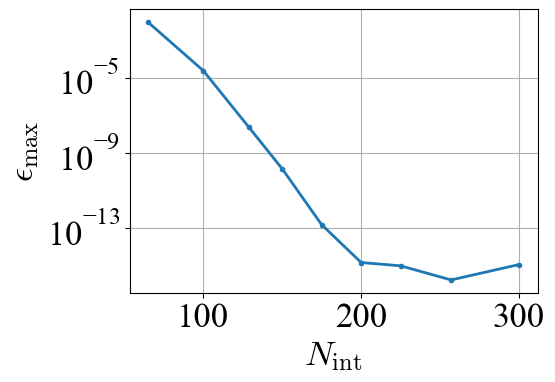

In [26]:
import matplotlib.pyplot as plt


def exp_fit(x, a, b, c):
    return a * np.exp(-b * x) + c


size = 25
params = {
    "figure.figsize": (6, 4.5),
    "legend.fontsize": "xx-large",
    "axes.labelsize": size,
    "axes.titlesize": "xx-large",
    "xtick.labelsize": size,
    "ytick.labelsize": size,
}
plt.rcParams.update(params)
plt.gcf().subplots_adjust(bottom=0.25, left=0.22)

ig = [65, 100, 129, 150, 175, 200, 225, 257, 300]
dx = np.array(ig, dtype=float)
tarr = np.array(A_list)
Uarr = np.array(U_list)
Uinf = np.zeros_like(Uarr[0])
tinf = np.zeros_like(tarr[0])
fitrange = slice(-3, None)
for i in range(L):
    # pU = np.polyfit(dx[fitrange], np.log(Uarr[fitrange, i]), 1)
    # Uinf[i] = np.exp(pU[1])
    popU, pcovU = curve_fit(exp_fit, dx[fitrange], Uarr[fitrange, i])
    Uinf[i] = popU[2]
    # for j in range(L):
    #     pt = np.polyfit(dx[fitrange], np.log(abs(tarr[fitrange, i, j])), 1)
    #     tinf[i, j] = np.exp(pt[1])

max_err = np.zeros_like(dx)
for i in range(len(max_err)):
    met = np.max((abs(tarr[i]) - abs(tinf)) / abs(tinf))
    meu = np.max((abs(Uarr[i]) - abs(Uinf)) / abs(Uinf))
    me = meu
    print(f"R0x = {dx[i]} max_err U = {meu}")
    max_err[i] = me
plt.plot(dx, max_err, ".-", lw=2)

plt.xlabel("$N_\mathrm{int}$")
plt.ylabel("$\epsilon_\mathrm{max}$")
plt.yscale("log")
plt.grid()
plt.savefig("AppFig3.pdf")